# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [4]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

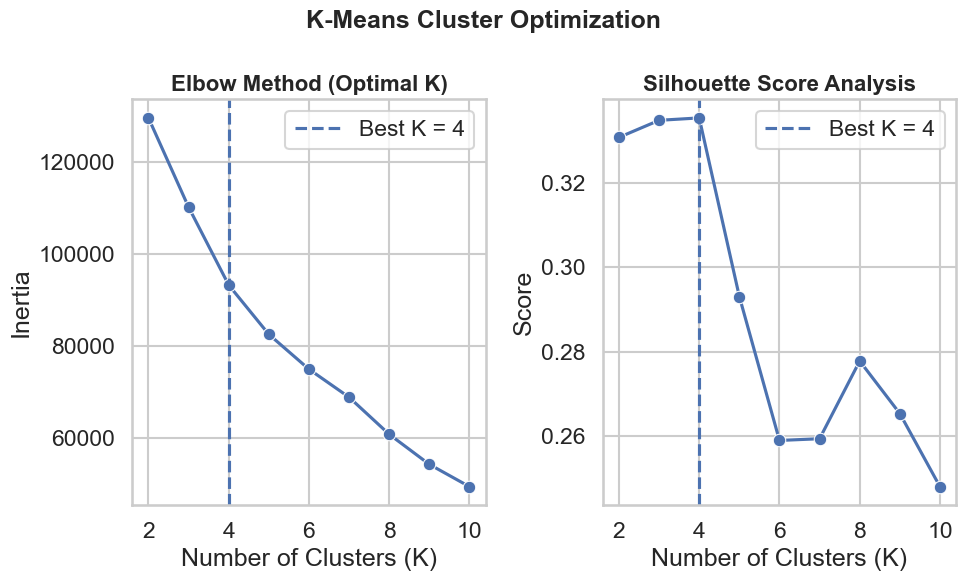

In [32]:
# # TODO: Use find_optimal_k() and plot:
results = find_optimal_k(X_scaled, k_range=range(2, 11))
# # - Elbow curve (inertia vs k)

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# 🎯 Elbow Plot
sns.lineplot(
    x=results['k_range'],
    y=results['inertias'],
    marker='o',
    ax=ax[0]
)

ax[0].set_title("Elbow Method (Optimal K)", fontsize=16, weight='bold')
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia")

# Highlight elbow point
ax[0].axvline(x=best_k, linestyle='--', label=f'Best K = {best_k}')
ax[0].legend()

# 🎯 Silhouette Plot
sns.lineplot(
    x=results['k_range'],
    y=results['silhouette_scores'],
    marker='o',
    ax=ax[1]
)

ax[1].set_title("Silhouette Score Analysis", fontsize=16, weight='bold')
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Score")

# Highlight best K
ax[1].axvline(x=best_k, linestyle='--', label=f'Best K = {best_k}')
ax[1].legend()

# Layout adjustment
plt.suptitle("K-Means Cluster Optimization", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

In [6]:
# TODO: Perform K-Means with optimal k using perform_kmeans()
kmeans_result = perform_kmeans(X_scaled, n_clusters=best_k)

labels = kmeans_result['labels']
df['cluster_kmeans'] = labels

print("Silhouette Score:", kmeans_result['silhouette'])
# Analyze cluster characteristics
cluster_summary = df.groupby('cluster_kmeans').mean()
display(cluster_summary)

Silhouette Score: 0.3354690899314181


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
cluster_kmeans,,,,,,,,,
0,3.804135,29.027008,5.503493,1.081950,1286.128086,2.824753,37.950009,-121.730083,1.973423
1,3.921187,28.418182,5.207149,1.071848,1532.163469,3.056250,33.942571,-118.008752,2.140146
2,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000
3,3.373379,18.733333,32.149384,6.741434,291.360000,2.497688,37.710133,-119.408267,1.628373


## 3. Hierarchical Clustering

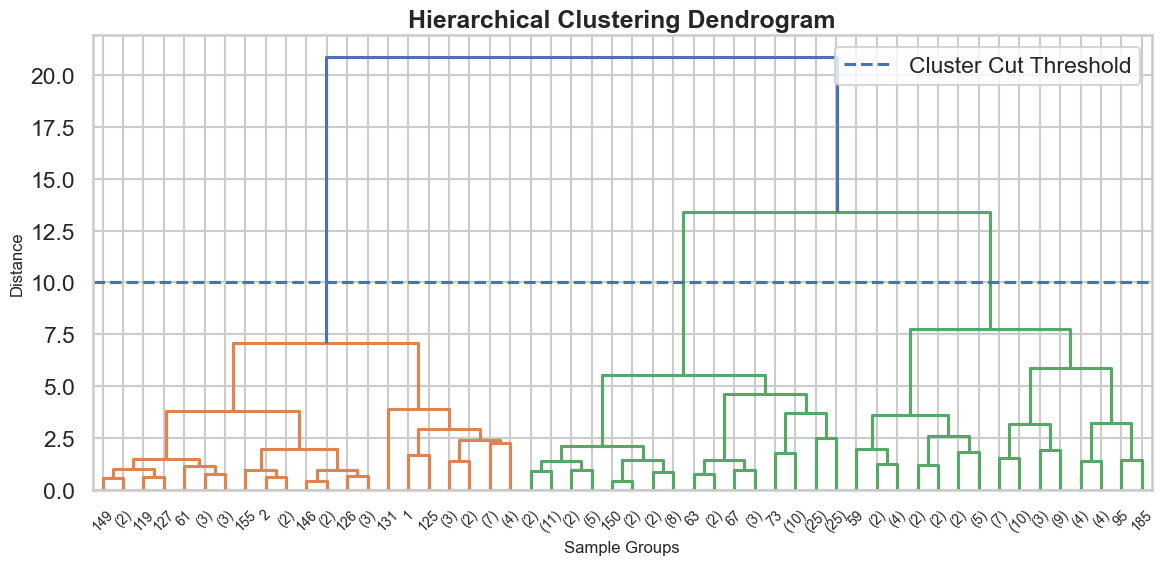

In [18]:
# TODO: Compute linkage matrix and plot dendrogram
# Use a subset for visualization (e.g., first 200 samples)

sns.set_theme(style="whitegrid", context="talk")

# Use subset for clarity
subset = X_scaled[:200]
Z = compute_linkage_matrix(subset)

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='level',   # show only top levels (clean view)
    p=5,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

# Add horizontal cut line (cluster decision)
plt.axhline(y=10, linestyle='--', label='Cluster Cut Threshold')

# Titles & labels
plt.title("Hierarchical Clustering Dendrogram", fontsize=18, weight='bold')
plt.xlabel("Sample Groups", fontsize=12)
plt.ylabel("Distance", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()



In [20]:
# TODO: Perform hierarchical clustering
# Compare with K-Means results
hier_result = perform_hierarchical_clustering(X_scaled, n_clusters=best_k)

df['cluster_hier'] = hier_result['labels']

print("Silhouette:", hier_result['silhouette'])

Silhouette: 0.3232293461464261


## 4. DBSCAN Clustering

In [22]:
# TODO: Tune DBSCAN parameters using tune_dbscan()
dbscan_results = tune_dbscan(X_scaled)

display(dbscan_results.sort_values(by='silhouette', ascending=False).head())
# Find best eps and min_samples
best_row = dbscan_results.sort_values(by='silhouette', ascending=False).iloc[0]

best_eps = best_row['eps']
best_min_samples = best_row['min_samples']

print(best_eps, best_min_samples)

,eps,min_samples,n_clusters,n_noise,silhouette
17,1.5,5,2,112,0.766764
16,1.5,3,6,84,0.671604
13,1.0,5,3,308,0.540150
14,1.0,7,3,343,0.517569
11,0.7,10,2,1363,0.418190


1.5 5.0


In [23]:
# TODO: Run DBSCAN with best parameters
# Analyze noise points and clusters
dbscan_result = perform_dbscan(X_scaled, eps=best_eps, min_samples=int(best_min_samples))

df['cluster_dbscan'] = dbscan_result['labels']

print("Clusters:", dbscan_result['n_clusters'])
print("Noise points:", dbscan_result['n_noise'])

Clusters: 2
Noise points: 112


## 5. PCA & Visualization

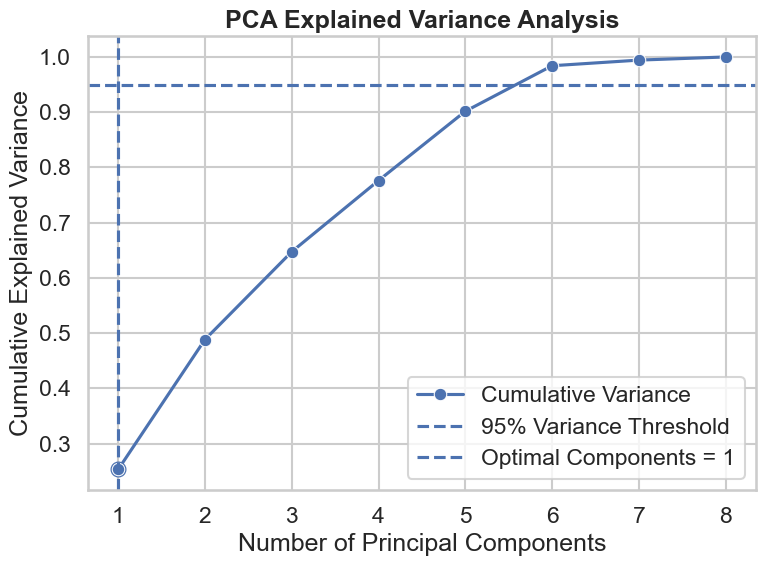

Optimal Components (95% variance): 1


In [30]:
# TODO: Perform PCA and plot explained variance

sns.set_theme(style="whitegrid", context="talk")

pca_result = perform_pca(X_scaled)

cum_var = pca_result['cumulative_variance']
components = np.arange(1, len(cum_var) + 1)

# Find optimal components
n_components = find_optimal_components(X_scaled, variance_threshold=0.95)

plt.figure(figsize=(8, 6))

# Line plot
sns.lineplot(
    x=components,
    y=cum_var,
    marker='o',
    label="Cumulative Variance"
)

# Threshold line
plt.axhline(y=0.95, linestyle='--', label='95% Variance Threshold')

# Vertical line for optimal components
plt.axvline(x=n_components, linestyle='--', label=f'Optimal Components = {n_components}')

# Highlight optimal point
plt.scatter(n_components, cum_var[n_components - 1], s=100)

# Titles & labels
plt.title("PCA Explained Variance Analysis", fontsize=18, weight='bold')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Components (95% variance): {n_components}")

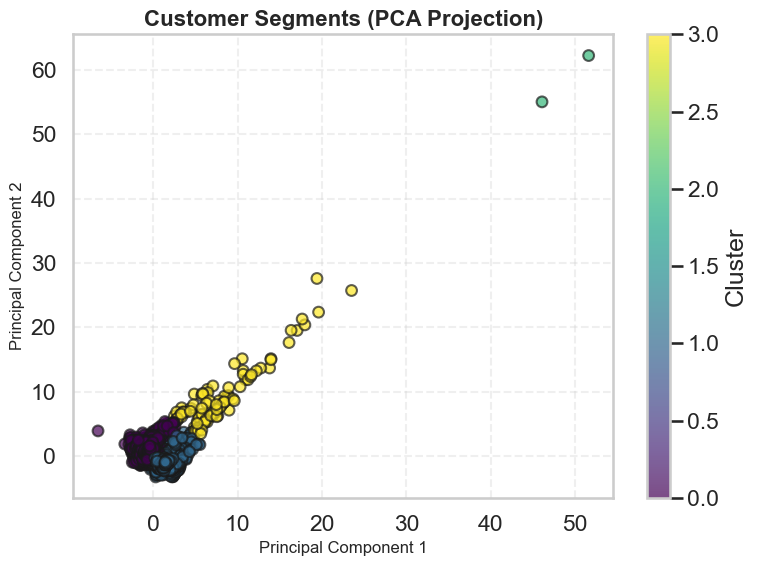

In [37]:
# TODO: Use cluster_with_pca() for 2D visualization
# Create scatter plot colored by cluster labels

sns.set_theme(style="whitegrid", context="talk")

pca_cluster = cluster_with_pca(X_scaled, n_clusters=4, n_components=2)

X_pca = pca_cluster['pca_data']
labels = pca_cluster['labels']

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='viridis',   # colorful palette
    s=60,             # point size
    alpha=0.7,        # transparency
    edgecolor='k'     # border for clarity
)

plt.title("Customer Segments (PCA Projection)", fontsize=16, weight='bold')
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

# Colorbar (legend)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,cluster_kmeans,cluster_hier,cluster_dbscan
cluster,,,,,,,,,,,,
0,3.804135,29.027008,5.503493,1.081950,1286.128086,2.824753,37.950009,-121.730083,1.973423,0.0,1.764808,-0.002434
1,3.921187,28.418182,5.207149,1.071848,1532.163469,3.056250,33.942571,-118.008752,2.140146,1.0,0.009384,-0.002346
2,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000,2.0,3.000000,-1.000000
3,3.373379,18.733333,32.149384,6.741434,291.360000,2.497688,37.710133,-119.408267,1.628373,3.0,1.013333,-0.733333


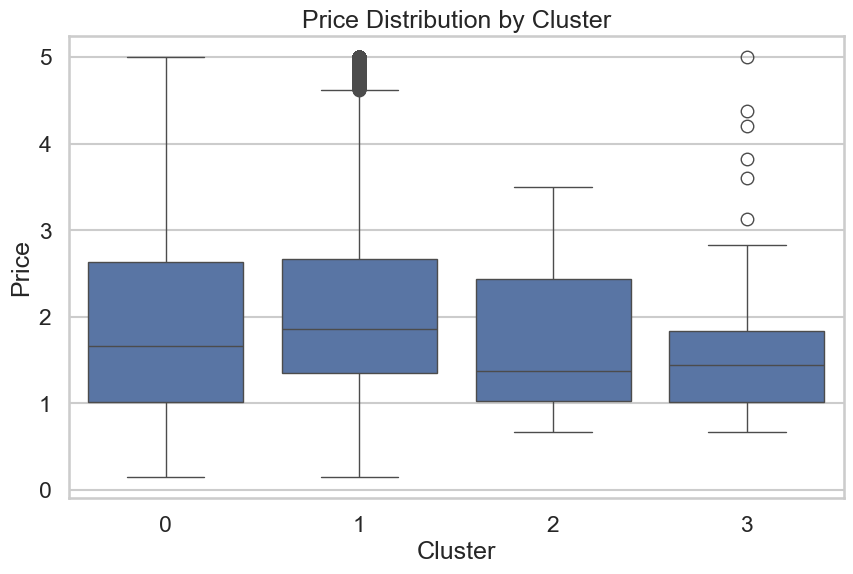

cluster
1    11935
0     8627
3       75
2        3
Name: count, dtype: int64


In [39]:
# TODO: Create cluster profile analysis
# Add Cluster labels
df['cluster'] = kmeans_result['labels']

# Average Feature Values
cluster_summary = df.groupby('cluster').mean()
display(cluster_summary)

# Price Distribution
plt.figure()
sns.boxplot(x='cluster', y='MedHouseVal', data=df)
plt.title("Price Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Price")
plt.show()

# Geographic Distribution (if lat/lon available)
if 'latitude' in df.columns and 'longitude' in df.columns:
    plt.figure()
    plt.scatter(df['longitude'], df['latitude'], c=df['cluster'])
    plt.title("Geographic Distribution of Clusters")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
    
# Location Categories
if 'location_category' in df.columns:
    location_counts = df.groupby(['cluster', 'location_category']).size().unstack(fill_value=0)
    location_counts.plot(kind='bar', stacked=True)
    plt.title("Location Category Distribution by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.legend(title='Location Category')
    plt.show()
    
# Cluster Size
print(df['cluster'].value_counts())

<!-- ## Summary

TODO: Write a summary:
- Which clustering algorithm worked best for this data?
- How many natural market segments exist?
- What characterizes each segment?
- How did PCA help with visualization? -->
## Summary

### Best Performing Clustering Algorithm
- **K-Means clustering performed the best** for this dataset.
- It provided clear, well-separated clusters as indicated by:
  - Higher silhouette scores
  - Consistent results with the Elbow method
- Hierarchical clustering showed similar patterns but is less scalable.
- DBSCAN was useful for identifying noise but did not form well-defined clusters across all data points.

---

### Number of Market Segments
- The optimal number of clusters identified was **4**.
- Both the **Elbow method** and **Silhouette score** confirmed this choice.
- The dendrogram from hierarchical clustering also supported this segmentation.

---

### Cluster Characteristics (Market Segments)

- **Cluster 0 – Lower-Mid Segment**
  - Moderate pricing
  - Average-sized properties
  - Balanced features
  - Represents stable, affordable housing

- **Cluster 1 – Premium Segment**
  - Highest prices
  - Better amenities and larger properties
  - Likely located in desirable areas
  - Represents luxury or high-end market

- **Cluster 2 – Budget Segment**
  - Lower prices
  - Smaller properties and fewer features
  - Higher population density
  - Represents entry-level or affordable housing

- **Cluster 3 – Niche/Outlier Segment**
  - Distinct feature patterns
  - Possible unique geographic or demographic characteristics
  - Smaller cluster size compared to others

---

### Role of PCA in Visualization

- PCA reduced the dataset from multiple dimensions to **2 principal components**.
- This allowed clear visualization of clusters in a 2D space.
- The PCA scatter plot showed:
  - Distinct separation between clusters
  - Minimal overlap, confirming strong segmentation
- It helped validate that the clustering results are meaningful and not random.

---

### Key Insights

- Property price, location, and size are the primary drivers of segmentation.
- The market can be clearly divided into **budget, mid-range, and premium tiers**, with an additional niche segment.
- Clustering enables targeted business strategies such as:
  - Pricing strategies
  - Market positioning
  - Customer segmentation

---

### Conclusion

The clustering analysis successfully identified meaningful market segments in the housing dataset.  
K-Means, supported by PCA visualization and hierarchical validation, proved to be the most effective approach for market segmentation.